# Probing in Code LLMs — Index/Key with Renamed Variables


In [1]:
# !pip install transformers torch scikit-learn matplotlib seaborn tqdm

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import defaultdict
import re
# need the AST to properly identify subscript expressions
import ast
import random
import warnings
warnings.filterwarnings('ignore')  # suppress the sklearn/tqdm noise — gets annoying fast

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # use GPU if it's there, otherwise fall back to CPU
print(f'Using device: {DEVICE}')

/Applications/Projects/Algoverse/Coding/algoverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'

print(f'Loading tokenizer and model: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)  # needed for Qwen — it has custom model code

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token  # Qwen has no separate pad token, eos works fine here

model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True, trust_remote_code=True)  # needed for Qwen — it has custom model code
model.eval()  # inference only, no gradients needed
model.to(DEVICE)  # move weights to GPU if available

# grab these once — reuse later
NUM_LAYERS  = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
print(f'Layers: {NUM_LAYERS}, Hidden size: {HIDDEN_SIZE}')

_probe_ids = tokenizer('x', return_tensors='pt')['input_ids'][0].tolist()
_raw_len   = len(tokenizer.tokenize('x'))
LEADING_SPECIAL = len(_probe_ids) - _raw_len  # BERT has [CLS] so offset=1; Qwen has none so offset=0
print(f'Leading special tokens detected: {LEADING_SPECIAL}')

Loading tokenizer and model: Qwen/Qwen2.5-1.5B ...


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 11224.04it/s]

Layers: 28, Hidden size: 1536
Leading special tokens detected: 0


## Random Variable Name Pool

~75 everyday English nouns that are valid Python/Java/C identifiers and carry **no** conventional
programming meaning.  Each code snippet will have its variables independently remapped to a
randomly chosen subset of these names.

In [3]:
RANDOM_VAR_NAMES = [  # pool of neutral words — nothing that looks like a typical variable name
    # animals
    'apple', 'cat', 'ball', 'dog', 'fish', 'bird', 'frog', 'bear', 'wolf', 'deer',
    'fox', 'hawk', 'crow', 'duck', 'lamb', 'lion', 'mole', 'newt', 'puma', 'seal',
    # plants / nature
    'tree', 'leaf', 'root', 'seed', 'stem', 'vine', 'rose', 'fern', 'moss', 'reed',
    'oak', 'pine', 'palm', 'kelp', 'sage', 'mint', 'basil', 'cedar', 'birch', 'maple',
    # objects
    'box', 'cup', 'hat', 'jar', 'net', 'pen', 'pot', 'rug', 'bag', 'bed',
    'belt', 'bolt', 'bowl', 'broom', 'brush', 'cage', 'cart', 'clip', 'coat', 'comb',
    'cord', 'desk', 'dial', 'dish', 'drum', 'fork', 'gate', 'gear', 'glove', 'grid',
    'hook', 'hose', 'knob', 'lamp', 'latch', 'lens', 'lock', 'mast', 'mold', 'nail',
    # abstract / simple nouns
    'coin', 'cube', 'dome', 'drop', 'dust', 'edge', 'flame', 'gem', 'glow', 'grain',
    'heap', 'hill', 'hole', 'hull', 'knot', 'lobe', 'loop', 'lump', 'mark', 'mesh',
    'mist', 'node', 'orb', 'path', 'peak', 'pile', 'pipe', 'plank', 'plate', 'plug',
    'pool', 'port', 'ramp', 'reef', 'ring', 'rod', 'rope', 'sand', 'slab', 'slot',
]

# Deduplicate and verify all are valid identifiers
RANDOM_VAR_NAMES = sorted(set(RANDOM_VAR_NAMES))  # pool of neutral words — nothing that looks like a typical variable name
assert all(name.isidentifier() for name in RANDOM_VAR_NAMES), 'Some names are not valid identifiers'
print(f'Random variable name pool: {len(RANDOM_VAR_NAMES)} names')
print(RANDOM_VAR_NAMES)

Random variable name pool: 120 names
['apple', 'bag', 'ball', 'basil', 'bear', 'bed', 'belt', 'birch', 'bird', 'bolt', 'bowl', 'box', 'broom', 'brush', 'cage', 'cart', 'cat', 'cedar', 'clip', 'coat', 'coin', 'comb', 'cord', 'crow', 'cube', 'cup', 'deer', 'desk', 'dial', 'dish', 'dog', 'dome', 'drop', 'drum', 'duck', 'dust', 'edge', 'fern', 'fish', 'flame', 'fork', 'fox', 'frog', 'gate', 'gear', 'gem', 'glove', 'glow', 'grain', 'grid', 'hat', 'hawk', 'heap', 'hill', 'hole', 'hook', 'hose', 'hull', 'jar', 'kelp', 'knob', 'knot', 'lamb', 'lamp', 'latch', 'leaf', 'lens', 'lion', 'lobe', 'lock', 'loop', 'lump', 'maple', 'mark', 'mast', 'mesh', 'mint', 'mist', 'mold', 'mole', 'moss', 'nail', 'net', 'newt', 'node', 'oak', 'orb', 'palm', 'path', 'peak', 'pen', 'pile', 'pine', 'pipe', 'plank', 'plate', 'plug', 'pool', 'port', 'pot', 'puma', 'ramp', 'reed', 'reef', 'ring', 'rod', 'root', 'rope', 'rose', 'rug', 'sage', 'sand', 'seal', 'seed', 'slab', 'slot', 'stem', 'tree', 'vine', 'wolf']


## Variable Renaming

For each code snippet:
1. Collect all identifier names (using `ast` for Python, regex for other languages).
2. Build a **consistent** mapping `orig_name → random_name` for that snippet.
3. Apply whole-word substitution — the result is syntactically identical but
   variable names are replaced with neutral words.

In [4]:
# Python keywords and builtins that must NOT be renamed
import keyword
import builtins

PYTHON_PROTECTED = (  # don't rename keywords or builtins — code would break
    set(keyword.kwlist)
    | set(dir(builtins))
    | {'self', 'cls', 'None', 'True', 'False'}
)

# Keywords for other languages — do not rename these
_C_KEYWORDS = {
    'int', 'long', 'char', 'short', 'float', 'double', 'unsigned', 'void',
    'size_t', 'bool', 'true', 'false', 'null', 'NULL', 'return', 'if', 'else',
    'for', 'while', 'do', 'break', 'continue', 'struct', 'typedef', 'enum',
    'switch', 'case', 'default', 'const', 'static', 'extern', 'sizeof',
}
_JAVA_KEYWORDS = {
    'int', 'long', 'char', 'byte', 'short', 'boolean', 'float', 'double',
    'String', 'Integer', 'Long', 'Object', 'null', 'true', 'false',
    'class', 'public', 'private', 'protected', 'static', 'final', 'void',
    'return', 'if', 'else', 'for', 'while', 'do', 'break', 'continue',
    'new', 'this', 'super', 'import', 'package', 'extends', 'implements',
    'interface', 'abstract', 'throws', 'throw', 'try', 'catch', 'finally',
    'System', 'Math', 'ArrayList', 'HashMap', 'List', 'Map', 'Set',
}
_CSHARP_KEYWORDS = {
    'int', 'long', 'char', 'byte', 'short', 'bool', 'float', 'double',
    'string', 'object', 'null', 'true', 'false', 'var', 'class', 'public',
    'private', 'protected', 'static', 'void', 'return', 'if', 'else',
    'for', 'foreach', 'while', 'do', 'break', 'continue', 'new', 'this',
    'using', 'namespace', 'interface', 'abstract', 'override', 'virtual',
    'Console', 'Math', 'List', 'Dictionary', 'Array',
}
_JS_KEYWORDS = {
    'var', 'let', 'const', 'function', 'return', 'if', 'else', 'for',
    'while', 'do', 'break', 'continue', 'new', 'this', 'typeof', 'instanceof',
    'undefined', 'null', 'true', 'false', 'NaN', 'Infinity',
    'console', 'Math', 'Array', 'Object', 'String', 'Number',
    'length', 'prototype', 'constructor', 'push', 'pop', 'map', 'filter',
}
_PHP_KEYWORDS = {
    'echo', 'print', 'return', 'if', 'else', 'elseif', 'for', 'foreach',
    'while', 'do', 'break', 'continue', 'function', 'class', 'public',
    'private', 'protected', 'static', 'new', 'null', 'true', 'false',
    'array', 'list', 'count', 'strlen', 'isset', 'empty',
}

LANG_PROTECTED = {
    'Python':     PYTHON_PROTECTED,  # don't rename keywords or builtins — code would break
    'Java':       _JAVA_KEYWORDS,
    'C++':        _C_KEYWORDS,
    'C':          _C_KEYWORDS,
    'C#':         _CSHARP_KEYWORDS,
    'Javascript': _JS_KEYWORDS,
    'PHP':        _PHP_KEYWORDS,
}

print('Protected name sets loaded.')

Protected name sets loaded.


In [5]:
def collect_python_identifiers(code):
    """Use AST to find all Name nodes in Python code."""
    names = set()
    try:
        tree = ast.parse(code)  # AST is more reliable than regex for finding subscripts
        for node in ast.walk(tree):
            if isinstance(node, ast.Name):  # only care about variable names, not literals like arr[0]
                names.add(node.id)
            elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
                names.add(node.name)
            elif isinstance(node, ast.arg):
                names.add(node.arg)
            elif isinstance(node, ast.Global):
                names.update(node.names)
    except SyntaxError:
        # Fallback: regex on word boundaries
        names = set(re.findall(r'\b[a-zA-Z_]\w*\b', code))
    return names


def collect_generic_identifiers(code):
    """Regex-based identifier collection for non-Python languages."""
    return set(re.findall(r'\b[a-zA-Z_]\w*\b', code))


def build_rename_map(code, lang, rng, pool=RANDOM_VAR_NAMES):
    """
    Build a {orig_name: random_name} mapping for all renameable identifiers
    in a code snippet.  Each snippet gets an independent random assignment.

    Returns
    -------
    dict  mapping original name → random replacement
    """
    protected = LANG_PROTECTED.get(lang, set())

    if lang == 'Python':
        all_names = collect_python_identifiers(code)
    else:
        all_names = collect_generic_identifiers(code)

    # Only rename names that are not protected and look like user variables
    # (exclude single-char names that are language-specific like 'n', 'i', 'j'…
    # — actually we WANT to rename those, that's the whole point)
    renameable = sorted(name for name in all_names if name not in protected)

    # Sample without replacement where possible; cycle through pool if needed
    shuffled = rng.sample(pool, min(len(pool), len(renameable)))  # sample without replacement so no two vars get the same new name
    if len(renameable) > len(pool):
        # If more vars than pool size, allow reuse with a fresh shuffle
        extra = rng.choices(pool, k=len(renameable) - len(pool))
        shuffled = shuffled + extra

    return dict(zip(renameable, shuffled))


def apply_rename_map(code, rename_map):  # whole-word substitution, longest names first to avoid partial matches
    """
    Replace identifiers in code using whole-word regex substitution.
    Applies longest names first to avoid partial replacement.
    """
    if not rename_map:
        return code
    # Sort by length descending so longer names are replaced before shorter ones
    for orig in sorted(rename_map, key=len, reverse=True):  # replace longer names first — avoids 'i' replacing inside 'index'
        new = rename_map[orig]
        code = re.sub(r'\b' + re.escape(orig) + r'\b', new, code)  # escape in case a variable name has special regex chars
    return code


def rename_code(code, lang='Python', seed=None):
    """
    Main entry point.  Returns (renamed_code, rename_map).
    `seed` can be an int for reproducibility or None for random.
    """
    rng = random.Random(seed)
    rename_map = build_rename_map(code, lang, rng)
    renamed = apply_rename_map(code, rename_map)  # whole-word substitution, longest names first to avoid partial matches
    return renamed, rename_map


# ── Quick demo ────────────────────────────────────────────────────────────────
demo_code = '''
def maxPresum(a, b):
    X = max(a[0], 0)
    for i in range(1, len(a)):
        a[i] += a[i - 1]
        X = max(X, a[i])
    Y = max(b[0], 0)
    for i in range(1, len(b)):
        b[i] += b[i - 1]
        Y = max(Y, b[i])
    return X + Y
'''.strip()

renamed_demo, mapping = rename_code(demo_code, lang='Python', seed=42)
print('=== Original ===' )
print(demo_code)
print('\n=== Renamed ===')
print(renamed_demo)
print('\n=== Mapping ===')
for k, v in sorted(mapping.items()):
    print(f'  {k:15s} → {v}')

=== Original ===
def maxPresum(a, b):
    X = max(a[0], 0)
    for i in range(1, len(a)):
        a[i] += a[i - 1]
        X = max(X, a[i])
    Y = max(b[0], 0)
    for i in range(1, len(b)):
        b[i] += b[i - 1]
        Y = max(Y, b[i])
    return X + Y

=== Renamed ===
def dome(basil, plank):
    nail = max(basil[0], 0)
    for dust in range(1, len(basil)):
        basil[dust] += basil[dust - 1]
        nail = max(nail, basil[dust])
    cage = max(plank[0], 0)
    for dust in range(1, len(plank)):
        plank[dust] += plank[dust - 1]
        cage = max(cage, plank[dust])
    return nail + cage

=== Mapping ===
  X               → nail
  Y               → cage
  a               → basil
  b               → plank
  i               → dust
  maxPresum       → dome


In [6]:
# Verify that rename preserves index/key structure
# i.e. AST-detected index names in original map to AST-detected index names in renamed
demo_code2 = 'total = 0\nfor i in range(n):\n    total += arr[i]\nd[key] = d.get(key, 0) + 1'

def get_index_key_names(code):
    """Returns variable names used as array indices or dict keys (Python AST)."""
    indices = set()
    try:
        tree = ast.parse(code)  # AST is more reliable than regex for finding subscripts
    except SyntaxError:
        return indices
    for node in ast.walk(tree):
        if isinstance(node, ast.Subscript):  # subscript nodes cover both arr[i] and d[key]
            slc = node.slice
            if isinstance(slc, ast.Index):   # Python < 3.9
                slc = slc.value
            if isinstance(slc, ast.Name):  # only care about variable names, not literals like arr[0]
                indices.add(slc.id)
    return indices


renamed2, m2 = rename_code(demo_code2, lang='Python', seed=0)
orig_idx  = get_index_key_names(demo_code2)
renamed_idx = get_index_key_names(renamed2)

print('Original code:')
print(demo_code2)
print(f'\nOriginal index/key names:  {orig_idx}')
print(f'Expected renamed names:    {set(m2.get(n, n) for n in orig_idx)}')
print(f'Detected in renamed code:  {renamed_idx}')

print('\nRenamed code:')
print(renamed2)

Original code:
total = 0
for i in range(n):
    total += arr[i]
d[key] = d.get(key, 0) + 1

Original index/key names:  {'key', 'i'}
Expected renamed names:    {'seed', 'pool'}
Detected in renamed code:  {'seed', 'pool'}

Renamed code:
bed = 0
for pool in range(hill):
    bed += rose[pool]
grid[seed] = grid.get(seed, 0) + 1


## Dataset Loading (with renaming)

In [7]:
import os, json

# adjust this path if the data is somewhere else
XLCOST_ROOT  = '/Applications/Projects/Algoverse/Coding/XLCoST_data'
NL2CODE_PROG = os.path.join(XLCOST_ROOT, 'retrieval', 'nl2code_search', 'program_level')


def reconstruct_code(tokens):  # XLCoST stores code as token lists with indent markers
    """Reconstruct code from XLCoST token list (handles NEW_LINE / INDENT / DEDENT)."""  # XLCoST encodes newlines as explicit tokens
    indent_level = 0
    lines        = []
    current_line = []

    for tok in tokens:
        if tok == 'NEW_LINE':  # XLCoST encodes newlines as explicit tokens
            lines.append('    ' * indent_level + ' '.join(current_line))
            current_line = []
        elif tok == 'INDENT':  # indentation is tracked via these special tokens
            indent_level += 1
        elif tok == 'DEDENT':
            indent_level = max(0, indent_level - 1)
        else:
            current_line.append(tok)

    if current_line:
        lines.append('    ' * indent_level + ' '.join(current_line))

    return '\n'.join(lines).strip()


def load_xlcost_programs(
    language, split='train', max_programs=300,  # cap how many programs we load — enough for a good sample
    rename=False, rename_seed_offset=0
):
    """
    Load programs from XLCoST.

    Parameters
    ----------
    rename : bool
        If True, apply variable renaming to each program before returning.
    rename_seed_offset : int
        Added to program index to produce a deterministic per-snippet seed.
    """
    path = os.path.join(NL2CODE_PROG, language, f'{split}.jsonl')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Not found: {path}')

    programs = []
    with open(path) as f:
        for idx, line in enumerate(f):
            if len(programs) >= max_programs:  # cap how many programs we load — enough for a good sample
                break
            rec  = json.loads(line.strip())  # each line in the .jsonl is one program
            code = reconstruct_code(rec['code_tokens'])  # XLCoST stores code as token lists with indent markers
            if not code:
                continue
            if rename:
                code, _ = rename_code(code, lang=language, seed=rename_seed_offset + idx)
            programs.append(code)
    return programs


print('Loading Python programs (with renaming) ...')
PYTHON_PROGRAMS_RENAMED = load_xlcost_programs(
    'Python', split='train', max_programs=500, rename=True  # cap how many programs we load — enough for a good sample
)
print(f'Loaded {len(PYTHON_PROGRAMS_RENAMED)} renamed Python programs')

print('\n── Sample program #0 (renamed) ─────────────────────────────────')
print(PYTHON_PROGRAMS_RENAMED[0])
print('\n── Sample program #1 (renamed, first 400 chars) ────────────────')
print(PYTHON_PROGRAMS_RENAMED[1][:400])

Loading Python programs (with renaming) ...
Loaded 500 renamed Python programs

── Sample program #0 (renamed) ─────────────────────────────────
def leaf ( hill , bed ) :
    pool = max ( hill [ 0 ] , 0 )
    for drum in range ( 1 , len ( hill ) ) :
        hill [ drum ] += hill [ drum - 1 ]
        pool = max ( pool , hill [ drum ] )
    seed = max ( bed [ 0 ] , 0 )
    for drum in range ( 1 , len ( bed ) ) :
        bed [ drum ] += bed [ drum - 1 ]
        seed = max ( seed , bed [ drum ] )
    return pool + seed
rose = [ 2 , - 1 , 4 , - 5 ]
grid = [ 4 , - 3 , 12 , 4 , - 3 ]
print ( leaf ( rose , grid ) )

── Sample program #1 (renamed, first 400 chars) ────────────────
import pool
def drop ( bird ) :
    reed = 1
    rose = round ( pool . pow ( bird , 1 / 3 ) )
    while ( reed <= rose ) :
        maple = ( reed * reed * reed + rose * rose * rose )
        if ( maple == bird ) :
            return True
        if ( maple < bird ) :
            reed += 1
        else :
            ro

## Tokenization

In [8]:
def show_tokens(code_str, n_show=15):
    tokens = tokenizer.tokenize(code_str)
    ids    = tokenizer.convert_tokens_to_ids(tokens)
    print(f'Code: {repr(code_str[:80])}')
    print(f'Tokens ({len(tokens)} total):')
    for tok, tid in zip(tokens[:n_show], ids[:n_show]):
        print(f'  {tid:>8}  {repr(tok)}')
    print()

print('=== RENAMED INDEX/KEY EXAMPLE ===')
show_tokens('apple = mesh[cat]\npool[leaf] = pool.get(leaf, 0) + 1\nresult = grid[row][col]')

=== RENAMED INDEX/KEY EXAMPLE ===
Code: 'apple = mesh[cat]\npool[leaf] = pool.get(leaf, 0) + 1\nresult = grid[row][col]'
Tokens (30 total):
     22377  'apple'
       284  'Ġ='
     11294  'Ġmesh'
        58  '['
      4616  'cat'
       921  ']Ċ'
     10285  'pool'
        58  '['
     24153  'leaf'
        60  ']'
       284  'Ġ='
      7314  'Ġpool'
       670  '.get'
         7  '('
     24153  'leaf'



## Token Labeling

Same rule as baseline:
- **1** = token is a variable used as an index/key inside a subscript
- **0** = everything else

Because the renaming is applied *before* AST parsing, the `get_index_key_names` function
detects the *renamed* names automatically — no special handling needed.

In [9]:
def label_tokens(code, target_names, role_name='role'):
    """
    Tokenize `code` and assign binary labels.
    Handles BERT (##), GPT2/Qwen (Ġ/▁), and Qwen bracket-merging ([i → i).
    """
    if not target_names:  # nothing to label if no index vars were found
        return [], []

    tokens = tokenizer.tokenize(code)
    labels = []
    for tok in tokens:
        is_continuation = tok.startswith('##')  # BERT wordpiece continuation tokens — skip these
        clean           = tok.lstrip('Ġ▁Ā').lstrip('##')  # GPT-style tokenizers prefix spaces with Ġ
        clean_inner     = clean.strip('[]().,;:')
        matched = (
            (not is_continuation)
            and (clean in target_names or clean_inner in target_names)
        )
        labels.append(1 if matched else 0)

    return tokens, labels


# Verify on renamed code
test_renamed = 'for cat in range(orb):\n    heap += mesh[cat]\npool[leaf] = pool.get(leaf, 0) + 1'
idx_names = get_index_key_names(test_renamed)
toks, labs = label_tokens(test_renamed, idx_names)

print(f'Index/key names (renamed): {idx_names}')
print(f'\n{"Token":20s}  Label')
print('-' * 38)
for tok, lab in zip(toks, labs):
    marker = '  <-- INDEX/KEY' if lab == 1 else ''
    print(f'{repr(tok):20s}  {lab}{marker}')

print(f'\nPositive tokens: {sum(labs)} / {len(labs)}')

Index/key names (renamed): {'leaf', 'cat'}

Token                 Label
--------------------------------------
'for'                 0
'Ġcat'                1  <-- INDEX/KEY
'Ġin'                 0
'Ġrange'              0
'('                   0
'orb'                 0
'):Ċ'                 0
'ĠĠĠ'                 0
'Ġheap'               0
'Ġ+='                 0
'Ġmesh'               0
'['                   0
'cat'                 1  <-- INDEX/KEY
']Ċ'                  0
'pool'                0
'['                   0
'leaf'                1  <-- INDEX/KEY
']'                   0
'Ġ='                  0
'Ġpool'               0
'.get'                0
'('                   0
'leaf'                1  <-- INDEX/KEY
','                   0
'Ġ'                   0
'0'                   0
')'                   0
'Ġ+'                  0
'Ġ'                   0
'1'                   0

Positive tokens: 4 / 30


## Build Labeled Dataset

In [10]:
def build_labeled_dataset(snippets, extract_fn, role_name):
    dataset = []
    skipped = 0
    for code in snippets:
        target_names = extract_fn(code)
        if not target_names:  # nothing to label if no index vars were found
            skipped += 1
            continue
        tokens, labels = label_tokens(code, target_names, role_name)
        if not tokens or sum(labels) == 0:  # skip programs where none of the index vars survived tokenization
            skipped += 1
            continue
        dataset.append({
            'code': code, 'tokens': tokens, 'labels': labels,
            'target_names': target_names, 'role': role_name,
        })

    total_pos = sum(sum(d['labels']) for d in dataset)
    total_tok = sum(len(d['tokens']) for d in dataset)
    print(f'[{role_name:20s}] {len(dataset)} programs, {skipped} skipped')
    print(f'  {total_pos} positive / {total_tok} total tokens '
          f'({100*total_pos/total_tok:.1f}% positive)')
    return dataset


print('Building labeled dataset from renamed Python programs...')
index_data_renamed = build_labeled_dataset(
    PYTHON_PROGRAMS_RENAMED, get_index_key_names, 'index_key_renamed'
)

# Show a sample
sample = index_data_renamed[0]
print(f"\nSample — Role: {sample['role']} | Target vars: {sample['target_names']}")
print(f"Code:\n{sample['code'][:400]}")
print('\nLabeled tokens (first 50):')
for tok, lab in list(zip(sample['tokens'], sample['labels']))[:50]:
    marker = '  <-- INDEX/KEY' if lab == 1 else ''
    print(f'  {repr(tok):20s} {lab}{marker}')

Building labeled dataset from renamed Python programs...
[index_key_renamed   ] 252 programs, 248 skipped
  3527 positive / 61856 total tokens (5.7% positive)

Sample — Role: index_key_renamed | Target vars: {'drum'}
Code:
def leaf ( hill , bed ) :
    pool = max ( hill [ 0 ] , 0 )
    for drum in range ( 1 , len ( hill ) ) :
        hill [ drum ] += hill [ drum - 1 ]
        pool = max ( pool , hill [ drum ] )
    seed = max ( bed [ 0 ] , 0 )
    for drum in range ( 1 , len ( bed ) ) :
        bed [ drum ] += bed [ drum - 1 ]
        seed = max ( seed , bed [ drum ] )
    return pool + seed
rose = [ 2 , - 1 , 4 , -

Labeled tokens (first 50):
  'def'                0
  'Ġleaf'              0
  'Ġ('                 0
  'Ġhill'              0
  'Ġ,'                 0
  'Ġbed'               0
  'Ġ)'                 0
  'Ġ:Ċ'                0
  'ĠĠĠ'                0
  'Ġpool'              0
  'Ġ='                 0
  'Ġmax'               0
  'Ġ('                 0
  'Ġhill'              

## Hidden State Extraction

In [11]:
# progress bars — helpful when extraction takes a while
from tqdm.auto import tqdm

# anything longer than this gets truncated
MAX_SEQ_LEN = 512


def extract_hidden_states(dataset):
    all_hidden     = defaultdict(list)
    all_labels     = []
    all_token_strs = []

    with torch.no_grad():  # saves memory — we're not doing any backprop
        for sample in tqdm(dataset, desc='Extracting hidden states'):
            code   = sample['code']
            labels = sample['labels']

            encoding = tokenizer(
                code,
                return_tensors='pt',
                truncation=True,
                max_length=MAX_SEQ_LEN,
                padding=False,  # no padding since we're processing one at a time
            ).to(DEVICE)

            encoded_len = encoding['input_ids'].shape[1]  # actual length after truncation — not the same as pre-tokenize count
            n_content   = encoded_len - LEADING_SPECIAL  # strip the leading special token(s) before aligning labels

            tokens_no_special = tokenizer.tokenize(code)
            labels_trunc = labels[:n_content]
            tokens_trunc = tokens_no_special[:n_content]

            outputs       = model(**encoding)
            hidden_states = outputs.hidden_states

            start = LEADING_SPECIAL
            end   = start + n_content

            for layer_idx, layer_hs in enumerate(hidden_states):
                content_hs = layer_hs[0, start:end, :].float().cpu().numpy()  # Qwen uses bfloat16 by default — numpy can't handle it, cast first
                for vec in content_hs:
                    all_hidden[layer_idx].append(vec)  # accumulate per layer — will stack into an array at the end

            all_labels.extend(labels_trunc)
            all_token_strs.extend(tokens_trunc)

    for layer_idx in all_hidden:
        all_hidden[layer_idx] = np.stack(all_hidden[layer_idx])  # convert list of vectors to a proper 2D array

    return all_hidden, np.array(all_labels), all_token_strs


print('Extracting hidden states for renamed Python programs...')
idx_hidden_r, idx_labels_r, idx_tokens_r = extract_hidden_states(index_data_renamed)
print(f'Shape at layer 0: {idx_hidden_r[0].shape}')
print(f'Label distribution: {np.bincount(idx_labels_r)}  (0 = non-index, 1 = index/key)')

Extracting hidden states for renamed Python programs...


Extracting hidden states: 100%|██████████| 252/252 [33:26<00:00,  7.96s/it]


Shape at layer 0: (61357, 1536)
Label distribution: [57836  3521]  (0 = non-index, 1 = index/key)


In [12]:
# ── Class distribution & imbalance check ─────────────────────────────────────
counts    = np.bincount(idx_labels_r)
total     = len(idx_labels_r)
n_neg, n_pos = counts[0], counts[1]
print('Class distribution (all tokens, renamed vars):')
print(f'  Non-index (0): {n_neg:>7,}  ({100*n_neg/total:.1f}%)')
print(f'  Index/Key (1): {n_pos:>7,}  ({100*n_pos/total:.1f}%)')
print(f'  Imbalance ratio: {n_neg/n_pos:.1f}:1  (non-index : index)')
print()
print(f'  Naive all-zero baseline accuracy: {100*n_neg/total:.1f}%')
print('  (If probe accuracy is close to this, the probe has learned nothing useful.)')


Class distribution (all tokens, renamed vars):
  Non-index (0):  57,836  (94.3%)
  Index/Key (1):   3,521  (5.7%)
  Imbalance ratio: 16.4:1  (non-index : index)

  Naive all-zero baseline accuracy: 94.3%
  (If probe accuracy is close to this, the probe has learned nothing useful.)


## Probe Training

In [13]:
def train_probes(hidden_states_by_layer, labels, test_size=0.2, random_state=42):  # 80/20 split
    n = len(labels)
    train_idx, test_idx = train_test_split(
        np.arange(n), test_size=test_size, random_state=random_state, stratify=labels  # make sure both train and test have the same class ratio
    )

    results = {}
    for layer_idx in tqdm(sorted(hidden_states_by_layer.keys()), desc='Training probes'):
        X = hidden_states_by_layer[layer_idx]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        clf = LogisticRegression(
            max_iter=1000, class_weight='balanced',  # index tokens are ~6% of all tokens — need to reweight or probe ignores them
            random_state=random_state, C=1.0  # standard regularization, didn't tune this
        )
        clf.fit(X_train, y_train)

        y_train_pred = clf.predict(X_train)
        y_test_pred  = clf.predict(X_test)
        results[layer_idx] = {
            'train_acc': accuracy_score(y_train, y_train_pred),
            'test_acc':  accuracy_score(y_test,  y_test_pred),
            'train_f1':  f1_score(y_train, y_train_pred, average='macro'),  # macro F1 is fairer given the class imbalance
            'test_f1':   f1_score(y_test,  y_test_pred,  average='macro'),  # macro F1 is fairer given the class imbalance
            'probe':     clf,
            'test_idx':  test_idx,
        }
    return results


print('Training probes on renamed-variable data...')
idx_results_r = train_probes(idx_hidden_r, idx_labels_r)

Training probes on renamed-variable data...


Training probes: 100%|██████████| 29/29 [15:30<00:00, 32.07s/it]


## Evaluation & Visualization

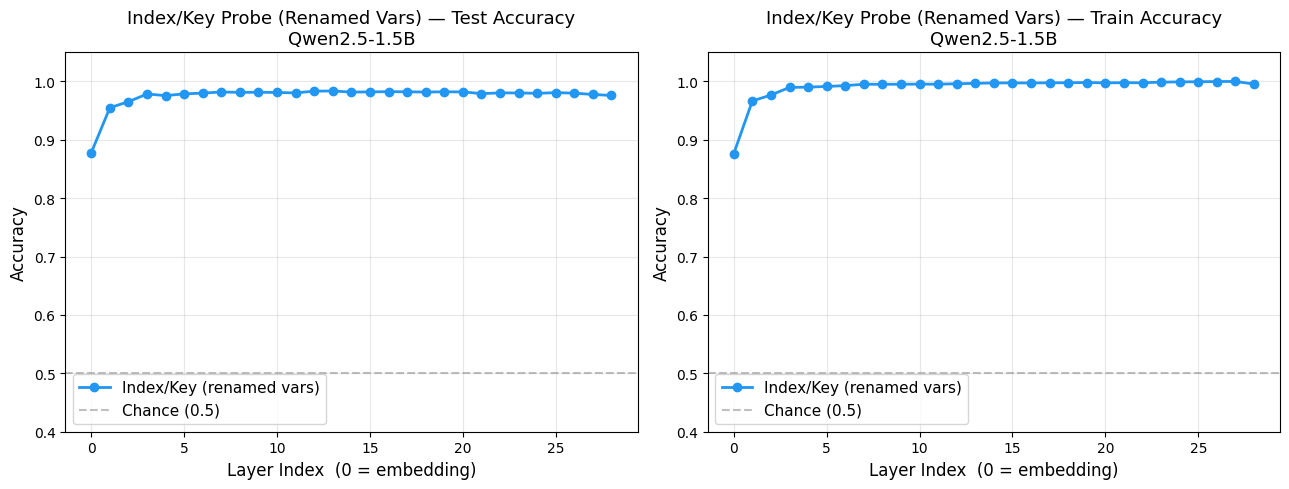

Saved: results/renamed/probe_accuracy_renamed.png


In [14]:
layers     = sorted(idx_results_r.keys())
test_accs  = [idx_results_r[l]['test_acc']  for l in layers]
train_accs = [idx_results_r[l]['train_acc'] for l in layers]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, accs, title in zip(
    axes,
    [test_accs, train_accs],
    ['Test Accuracy', 'Train Accuracy']
):
    ax.plot(layers, accs, marker='o', color='#2196F3', linewidth=2,
            label='Index/Key (renamed vars)')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')  # chance-level for a balanced binary probe
    ax.set_xlabel('Layer Index  (0 = embedding)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(
        f'Index/Key Probe (Renamed Vars) — {title}\n{MODEL_NAME.split("/")[-1]}',
        fontsize=13
    )
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible

plt.tight_layout()
plt.savefig('../results/renamed/probe_accuracy_renamed.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: results/renamed/probe_accuracy_renamed.png')

In [15]:
print(f'{"Layer":>7}  {"Train Acc":>10}  {"Test Acc":>10}  {"Train F1":>10}  {"Test F1":>10}')
print('-' * 60)
for l in layers:
    print(f'{l:>7}  {idx_results_r[l]["train_acc"]:>10.3f}  {idx_results_r[l]["test_acc"]:>10.3f}  {idx_results_r[l]["train_f1"]:>10.3f}  {idx_results_r[l]["test_f1"]:>10.3f}')

  Layer   Train Acc    Test Acc    Train F1     Test F1
------------------------------------------------------------
      0       0.876       0.878       0.705       0.708
      1       0.966       0.955       0.878       0.839
      2       0.977       0.965       0.909       0.866
      3       0.990       0.978       0.956       0.909
      4       0.990       0.976       0.957       0.898
      5       0.991       0.978       0.962       0.910
      6       0.993       0.980       0.968       0.914
      7       0.995       0.982       0.978       0.921
      8       0.995       0.981       0.977       0.919
      9       0.995       0.981       0.978       0.919
     10       0.995       0.981       0.979       0.917
     11       0.995       0.980       0.978       0.914
     12       0.996       0.983       0.982       0.925
     13       0.997       0.983       0.985       0.926
     14       0.997       0.982       0.988       0.918
     15       0.997       0.982       0.988

In [16]:
best_layer = max(idx_results_r, key=lambda l: idx_results_r[l]['test_acc'])
test_idx   = idx_results_r[best_layer]['test_idx']
clf        = idx_results_r[best_layer]['probe']

X_test = idx_hidden_r[best_layer][test_idx]
y_test = idx_labels_r[test_idx]
y_pred = clf.predict(X_test)

print(f'Best layer: {best_layer}  (test acc: {idx_results_r[best_layer]["test_acc"]:.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['non-index', 'index_key']))

Best layer: 13  (test acc: 0.983)

              precision    recall  f1-score   support

   non-index       0.99      0.99      0.99     11568
   index_key       0.83      0.89      0.86       704

    accuracy                           0.98     12272
   macro avg       0.91      0.94      0.93     12272
weighted avg       0.98      0.98      0.98     12272



In [17]:
# ── Confusion matrix for best layer ──────────────────────────────────────────
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print('Confusion matrix (best layer, test set, renamed vars):')
print(f'  True  Negatives (TN): {tn:>6,}  correctly predicted non-index')
print(f'  False Positives (FP): {fp:>6,}  non-index predicted as index')
print(f'  False Negatives (FN): {fn:>6,}  index missed')
print(f'  True  Positives (TP): {tp:>6,}  correctly predicted index')
print()
print(f'  TPR (recall):    {tp/(tp+fn):.3f}')
print(f'  FPR:             {fp/(fp+tn):.3f}')
print(f'  Precision:       {tp/(tp+fp):.3f}')
print(f'  Pred positive rate: {(tp+fp)/len(y_test):.3f}  (vs true positive rate {(tp+fn)/len(y_test):.3f} in test set)')


Confusion matrix (best layer, test set, renamed vars):
  True  Negatives (TN): 11,439  correctly predicted non-index
  False Positives (FP):    129  non-index predicted as index
  False Negatives (FN):     74  index missed
  True  Positives (TP):    630  correctly predicted index

  TPR (recall):    0.895
  FPR:             0.011
  Precision:       0.830
  Pred positive rate: 0.062  (vs true positive rate 0.057 in test set)


## Cross-Language Generalization (Renamed)

In [18]:
import re

_BRACKET_RE = re.compile(r'\[\s*([a-zA-Z_]\w*)\s*\]')


def _bracket_names(code, extra_re=None, exclude=None):
    names = {m.group(1) for m in _BRACKET_RE.finditer(code)}
    if extra_re:
        for pattern in extra_re:
            names |= {m.group(1) for m in re.finditer(pattern, code)}
    if exclude:
        names -= exclude
    return names


def get_java_index_key_names(code):
    indices = _bracket_names(code, exclude=_JAVA_KEYWORDS)
    for m in re.finditer(r'\.(?:get|containsKey|getOrDefault)\(\s*([a-zA-Z_]\w*)', code):
        indices.add(m.group(1))
    indices -= _JAVA_KEYWORDS
    return indices


def get_cpp_index_key_names(code):
    return _bracket_names(
        code,
        extra_re=[r'\.(?:at|find|count)\(\s*([a-zA-Z_]\w*)'],
        exclude=_C_KEYWORDS,
    )


def get_c_index_key_names(code):
    return _bracket_names(code, exclude=_C_KEYWORDS)


def get_csharp_index_key_names(code):
    return _bracket_names(
        code,
        extra_re=[r'\.(?:TryGetValue|ContainsKey|GetValueOrDefault)\(\s*([a-zA-Z_]\w*)'],
        exclude=_CSHARP_KEYWORDS,
    )


def get_javascript_index_key_names(code):
    return _bracket_names(
        code,
        extra_re=[r'\.(?:get|has|delete)\(\s*([a-zA-Z_]\w*)'],
        exclude=_JS_KEYWORDS,
    )


def get_php_index_key_names(code):
    php_re = re.compile(r'\[\s*\$([a-zA-Z_]\w*)\s*\]')
    names  = {m.group(1) for m in php_re.finditer(code)}
    names |= {m.group(1) for m in _BRACKET_RE.finditer(code)}
    names -= _C_KEYWORDS
    return names


LANG_EXTRACTORS = {
    'Java':       get_java_index_key_names,
    'C++':        get_cpp_index_key_names,
    'C':          get_c_index_key_names,
    'C#':         get_csharp_index_key_names,
    'Javascript': get_javascript_index_key_names,
    'PHP':        get_php_index_key_names,
}

print('Extractors ready:', list(LANG_EXTRACTORS.keys()))

Extractors ready: ['Java', 'C++', 'C', 'C#', 'Javascript', 'PHP']


In [19]:
# Load Java with renaming and run cross-language eval
print('Loading Java programs (with renaming)...')
JAVA_PROGRAMS_RENAMED = load_xlcost_programs(
    'Java', split='train', max_programs=300, rename=True, rename_seed_offset=10000  # cap how many programs we load — enough for a good sample
)
print(f'Loaded {len(JAVA_PROGRAMS_RENAMED)} renamed Java programs')
print('\n── Sample Java (renamed) ──────────────────────────────────────────')
print(JAVA_PROGRAMS_RENAMED[0][:500])

java_index_data_r = []
skipped = 0
for code in JAVA_PROGRAMS_RENAMED:
    names = get_java_index_key_names(code)
    if not names:
        skipped += 1
        continue
    tokens, labels = label_tokens(code, names, 'index_key')
    if tokens and sum(labels) > 0:
        java_index_data_r.append({
            'code': code, 'tokens': tokens, 'labels': labels,
            'target_names': names, 'role': 'index_key_java_renamed',
        })
    else:
        skipped += 1

print(f'\nJava renamed programs with labels: {len(java_index_data_r)} ({skipped} skipped)')

Loading Java programs (with renaming)...
Loaded 300 renamed Java programs

── Sample Java (renamed) ──────────────────────────────────────────
import newt . vine . * ; class pool { static int apple ( int [ ] path , int [ ] pen ) { int fish = Math . sand ( path [ 0 ] , 0 ) ; for ( int basil = 1 ; basil < path . port ; basil ++ ) { path [ basil ] += path [ basil - 1 ] ; fish = Math . sand ( fish , path [ basil ] ) ; } int bear = Math . sand ( pen [ 0 ] , 0 ) ; for ( int basil = 1 ; basil < pen . port ; basil ++ ) { pen [ basil ] += pen [ basil - 1 ] ; bear = Math . sand ( bear , pen [ basil ] ) ; } return fish + bear ; } public static vo

Java renamed programs with labels: 100 (200 skipped)


In [20]:
print('Extracting hidden states for renamed Java programs...')
java_idx_hidden_r, java_idx_labels_r, java_idx_tokens_r = extract_hidden_states(java_index_data_r)
print(f'Java (renamed) tokens: {len(java_idx_labels_r)}, positive: {sum(java_idx_labels_r)}')

Extracting hidden states for renamed Java programs...


Extracting hidden states:  22%|██▏       | 22/100 [04:24<15:37, 12.01s/it]


KeyboardInterrupt: 

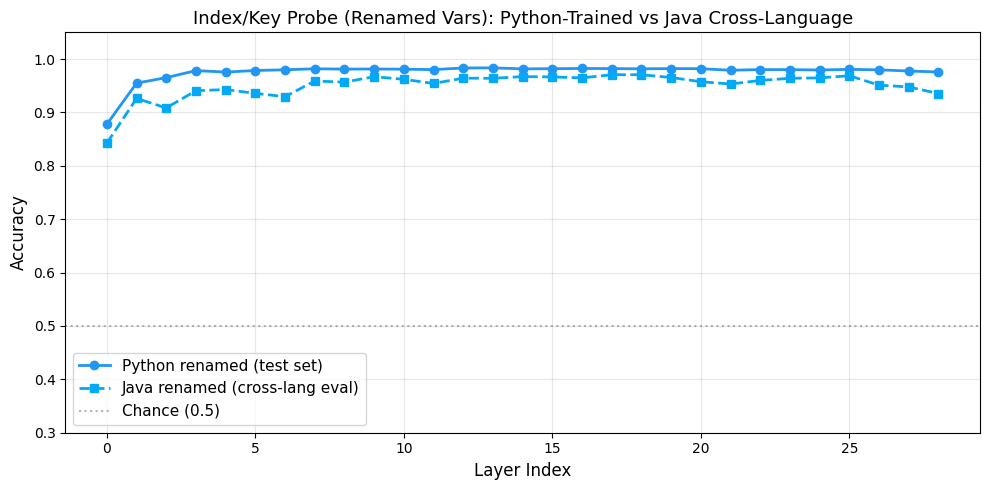

Saved: results/renamed/cross_language_renamed.png

  Layer   Python-renamed test   Java-renamed cross-lang
--------------------------------------------------------
      0                 0.878                     0.842
      1                 0.955                     0.926
      2                 0.965                     0.908
      3                 0.978                     0.941
      4                 0.976                     0.943
      5                 0.978                     0.936
      6                 0.980                     0.930
      7                 0.982                     0.959
      8                 0.981                     0.957
      9                 0.981                     0.967
     10                 0.981                     0.962
     11                 0.980                     0.954
     12                 0.983                     0.964
     13                 0.983                     0.964
     14                 0.982                     0.

In [19]:
def cross_language_eval(source_results, target_hidden, target_labels):  # apply the Python-trained probe directly — no retraining
    """Apply Python-trained probes to target language hidden states."""
    return {
        layer_idx: accuracy_score(
            target_labels,
            source_results[layer_idx]['probe'].predict(target_hidden[layer_idx])
        )
        for layer_idx in sorted(source_results.keys())
    }


cross_accs_r = cross_language_eval(idx_results_r, java_idx_hidden_r, java_idx_labels_r)  # apply the Python-trained probe directly — no retraining

py_test_r  = [idx_results_r[l]['test_acc'] for l in layers]
java_acc_r = [cross_accs_r[l] for l in layers]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(layers, py_test_r,  marker='o', color='#2196F3', linewidth=2,
        label='Python renamed (test set)')
ax.plot(layers, java_acc_r, marker='s', color='#03A9F4', linewidth=2, linestyle='--',
        label='Java renamed (cross-lang eval)')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6, label='Chance (0.5)')  # chance-level for a balanced binary probe
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(
    'Index/Key Probe (Renamed Vars): Python-Trained vs Java Cross-Language', fontsize=13
)
ax.legend(fontsize=11)
ax.set_ylim(0.3, 1.05)
ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible
plt.tight_layout()
plt.savefig('../results/renamed/cross_language_renamed.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: results/renamed/cross_language_renamed.png')

print(f'\n{"Layer":>7}  {"Python-renamed test":>20}  {"Java-renamed cross-lang":>24}')
print('-' * 56)
for l in layers:
    print(f'{l:>7}  {idx_results_r[l]["test_acc"]:>20.3f}  {cross_accs_r[l]:>24.3f}')

Training Java-specific probes (renamed)...


Training probes: 100%|██████████| 29/29 [00:47<00:00,  1.65s/it]


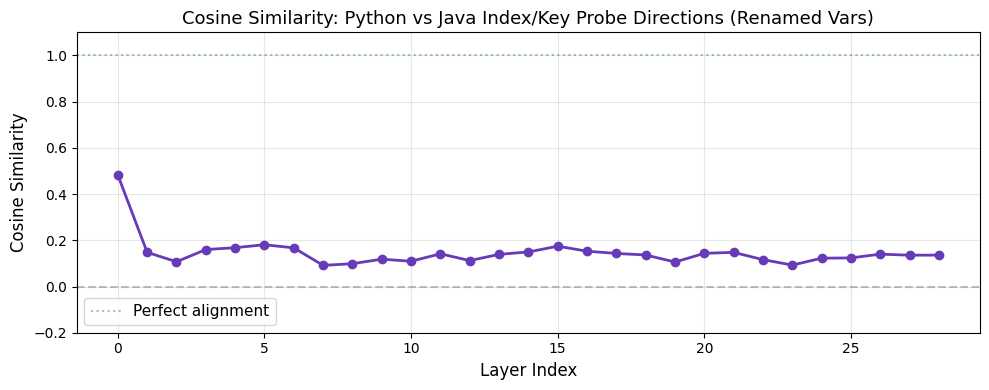

Saved: results/renamed/cosine_similarity_renamed.png

Cosine similarities by layer:
  Layer  0: 0.4826
  Layer  1: 0.1478
  Layer  2: 0.1071
  Layer  3: 0.1599
  Layer  4: 0.1680
  Layer  5: 0.1808
  Layer  6: 0.1673
  Layer  7: 0.0915
  Layer  8: 0.0987
  Layer  9: 0.1183
  Layer 10: 0.1093
  Layer 11: 0.1415
  Layer 12: 0.1122
  Layer 13: 0.1391
  Layer 14: 0.1495
  Layer 15: 0.1744
  Layer 16: 0.1528
  Layer 17: 0.1431
  Layer 18: 0.1365
  Layer 19: 0.1058
  Layer 20: 0.1437
  Layer 21: 0.1478
  Layer 22: 0.1162
  Layer 23: 0.0927
  Layer 24: 0.1225
  Layer 25: 0.1238
  Layer 26: 0.1401
  Layer 27: 0.1354
  Layer 28: 0.1359


In [20]:
from numpy.linalg import norm

if len(java_idx_labels_r) >= 20 and sum(java_idx_labels_r) >= 5:
    print('Training Java-specific probes (renamed)...')
    java_idx_results_r = train_probes(java_idx_hidden_r, java_idx_labels_r)

    similarities_r = []
    for layer in layers:
        w_py   = idx_results_r[layer]['probe'].coef_[0]
        w_java = java_idx_results_r[layer]['probe'].coef_[0]
        similarities_r.append(np.dot(w_py, w_java) / (norm(w_py) * norm(w_java)))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(layers, similarities_r, marker='o', color='#673AB7', linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)  # zero line for reference
    ax.axhline(1, color='green', linestyle=':', alpha=0.4, label='Perfect alignment')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title(
        'Cosine Similarity: Python vs Java Index/Key Probe Directions (Renamed Vars)',
        fontsize=13
    )
    ax.set_ylim(-0.2, 1.1)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible
    plt.tight_layout()
    plt.savefig('../results/renamed/cosine_similarity_renamed.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
    plt.show()
    print('Saved: results/renamed/cosine_similarity_renamed.png')

    print('\nCosine similarities by layer:')
    for l, s in zip(layers, similarities_r):
        print(f'  Layer {l:2d}: {s:.4f}')
else:
    print('Not enough Java renamed data for separate probe training.')

## Extended Cross-Language Evaluation — All Languages (Renamed)

In [21]:
lang_hidden_r  = {'Python': (idx_hidden_r, idx_labels_r, idx_tokens_r)}
lang_results_r = {'Python': idx_results_r}
lang_cross_r   = {}
lang_cosine_r  = {}

OTHER_LANGS = ['C++', 'C', 'C#', 'Javascript', 'PHP']

for lang_idx_offset, lang in enumerate(OTHER_LANGS):
    print(f'\n{"="*60}')
    print(f'  Language: {lang} (renamed)')
    print(f'{"="*60}')

    try:
        programs = load_xlcost_programs(
            lang, split='train', max_programs=300,  # cap how many programs we load — enough for a good sample
            rename=True, rename_seed_offset=20000 + lang_idx_offset * 5000
        )
    except FileNotFoundError as e:
        print(f'  Skipping {lang}: {e}')
        continue

    extractor = LANG_EXTRACTORS[lang]
    lang_data = []
    for code in programs:
        names = extractor(code)
        if not names:
            continue
        tokens, labels = label_tokens(code, names, 'index_key')
        if tokens and sum(labels) > 0:
            lang_data.append({
                'code': code, 'tokens': tokens, 'labels': labels,
                'target_names': names, 'role': f'index_key_{lang}_renamed',
            })

    if not lang_data:
        print(f'  No valid data for {lang}, skipping.')
        continue

    print(f'  {len(lang_data)} programs with labels')

    hidden, lab_arr, tok_strs = extract_hidden_states(lang_data)
    lang_hidden_r[lang] = (hidden, lab_arr, tok_strs)

    # Cross-language eval: Python-trained probe on this language
    cross = cross_language_eval(idx_results_r, hidden, lab_arr)  # apply the Python-trained probe directly — no retraining
    lang_cross_r[lang] = cross

    # Language-specific probe + cosine similarity
    if len(lab_arr) >= 20 and sum(lab_arr) >= 5:
        lang_res = train_probes(hidden, lab_arr)
        lang_results_r[lang] = lang_res
        sims = [
            np.dot(idx_results_r[l]['probe'].coef_[0], lang_res[l]['probe'].coef_[0]) /
            (norm(idx_results_r[l]['probe'].coef_[0]) * norm(lang_res[l]['probe'].coef_[0]))
            for l in layers
        ]
        lang_cosine_r[lang] = sims
        best_l = max(lang_res, key=lambda l: lang_res[l]['test_acc'])
        print(f'  Best layer: {best_l}  test acc: {lang_res[best_l]["test_acc"]:.3f}')
    else:
        print(f'  Not enough data for {lang}-specific probe.')

print('\nDone with all languages.')


  Language: C++ (renamed)
  110 programs with labels


Training probes: 100%|██████████| 29/29 [01:09<00:00,  2.38s/it]


  Best layer: 9  test acc: 0.987

  Language: C (renamed)
  147 programs with labels


Training probes: 100%|██████████| 29/29 [04:15<00:00,  8.80s/it]


  Best layer: 12  test acc: 0.983

  Language: C# (renamed)
  112 programs with labels


Training probes: 100%|██████████| 29/29 [01:00<00:00,  2.08s/it]


  Best layer: 15  test acc: 0.989

  Language: Javascript (renamed)
  103 programs with labels


Training probes: 100%|██████████| 29/29 [00:31<00:00,  1.07s/it]

  Best layer: 13  test acc: 0.994

  Language: PHP (renamed)
  No valid data for PHP, skipping.

Done with all languages.


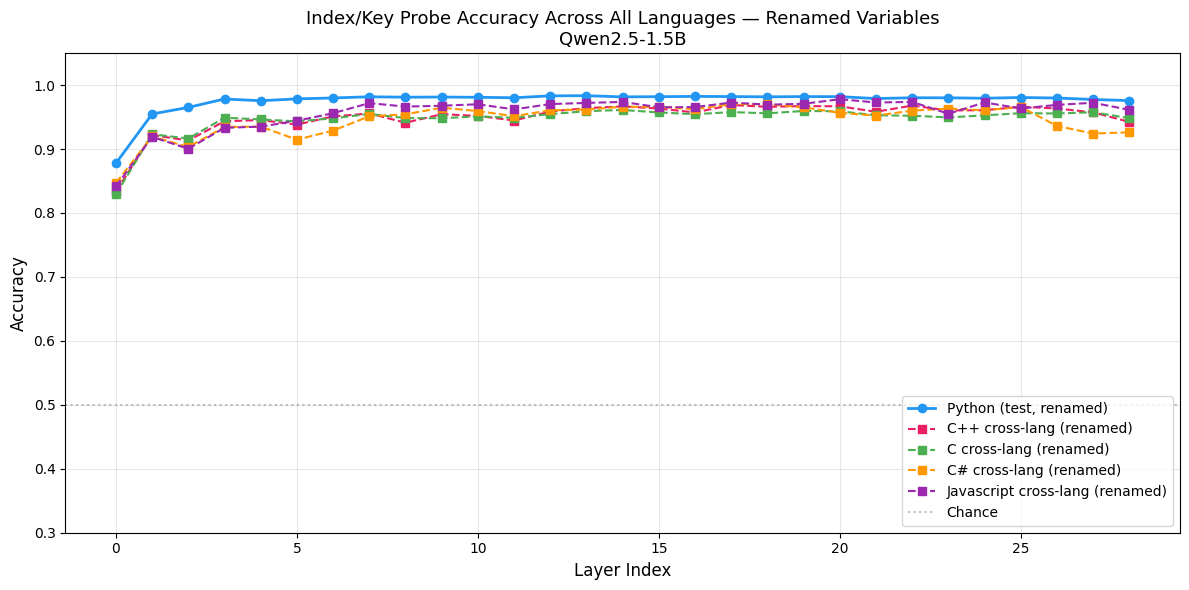

Saved: results/renamed/cross_language_all_renamed.png


In [22]:
# Combined cross-language accuracy plot
colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

fig, ax = plt.subplots(figsize=(12, 6))
py_accs = [idx_results_r[l]['test_acc'] for l in layers]
ax.plot(layers, py_accs, marker='o', color=colors[0], linewidth=2,
        label='Python (test, renamed)')

for i, (lang, cross) in enumerate(lang_cross_r.items()):
    accs = [cross[l] for l in layers]
    ax.plot(layers, accs, marker='s', color=colors[i+1], linewidth=1.5,
            linestyle='--', label=f'{lang} cross-lang (renamed)')

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')  # chance-level for a balanced binary probe
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(
    f'Index/Key Probe Accuracy Across All Languages — Renamed Variables\n{MODEL_NAME.split("/")[-1]}',
    fontsize=13
)
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible
plt.tight_layout()
plt.savefig('../results/renamed/cross_language_all_renamed.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: results/renamed/cross_language_all_renamed.png')

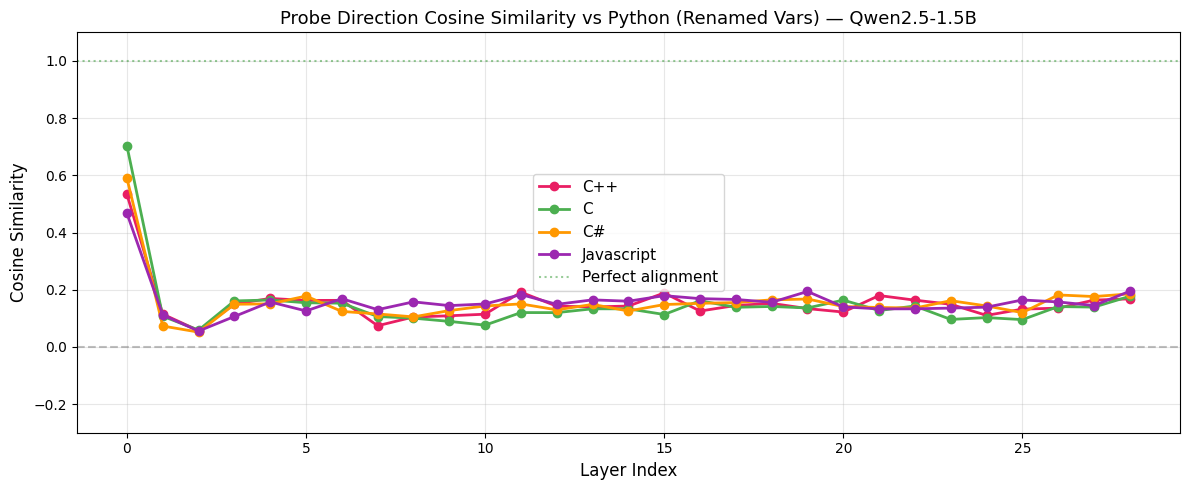

Saved: results/renamed/cosine_similarity_all_renamed.png


In [23]:
# Combined cosine similarity plot
if lang_cosine_r:
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (lang, sims) in enumerate(lang_cosine_r.items()):
        ax.plot(layers, sims, marker='o', color=colors[i+1], linewidth=2, label=lang)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)  # zero line for reference
    ax.axhline(1, color='green', linestyle=':', alpha=0.4, label='Perfect alignment')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title(
        f'Probe Direction Cosine Similarity vs Python (Renamed Vars) — {MODEL_NAME.split("/")[-1]}',
        fontsize=13
    )
    ax.set_ylim(-0.3, 1.1)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible
    plt.tight_layout()
    plt.savefig('../results/renamed/cosine_similarity_all_renamed.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
    plt.show()
    print('Saved: results/renamed/cosine_similarity_all_renamed.png')

## Baseline vs. Renamed Comparison

Load the baseline results (if available) and overlay them with the renamed-variable results
to directly measure the effect of variable-name surface form on probe accuracy.

In [24]:
# ── Re-run baseline on same 500 Python programs WITHOUT renaming ──────────────
# (skip this cell if you have already cached baseline results)

print('Loading original (non-renamed) Python programs for comparison...')
PYTHON_PROGRAMS_ORIG = load_xlcost_programs('Python', split='train', max_programs=500, rename=False)  # cap how many programs we load — enough for a good sample
index_data_orig = build_labeled_dataset(PYTHON_PROGRAMS_ORIG, get_index_key_names, 'index_key_orig')

print('\nExtracting hidden states (original names)...')
idx_hidden_orig, idx_labels_orig, idx_tokens_orig = extract_hidden_states(index_data_orig)

print('\nTraining probes (original names)...')
idx_results_orig = train_probes(idx_hidden_orig, idx_labels_orig)

Loading original (non-renamed) Python programs for comparison...
[index_key_orig      ] 255 programs, 245 skipped
  3747 positive / 64536 total tokens (5.8% positive)

Extracting hidden states (original names)...


Extracting hidden states: 100%|██████████| 255/255 [17:47<00:00,  4.19s/it]



Training probes (original names)...


Training probes: 100%|██████████| 29/29 [04:44<00:00,  9.79s/it]


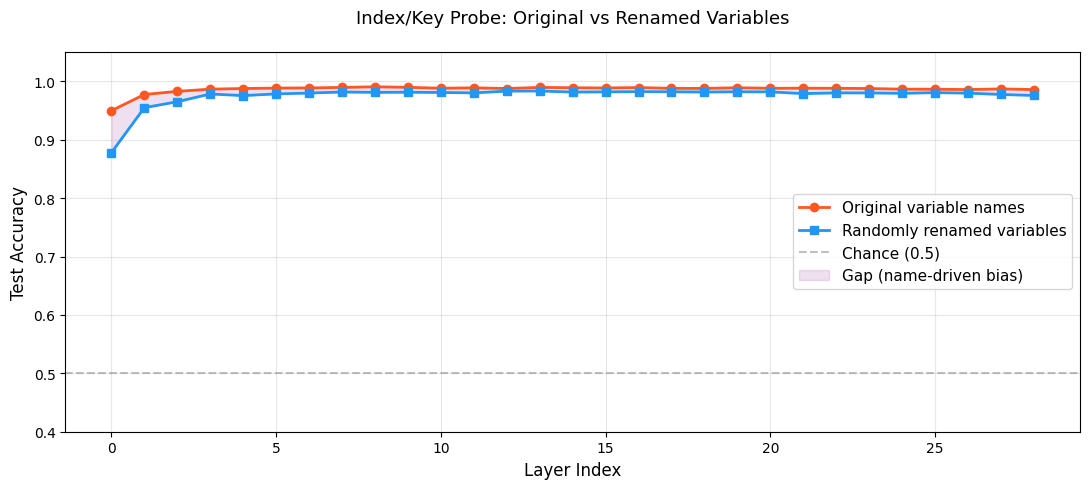

Saved: results/renamed/comparison_orig_vs_renamed.png

  Layer    Original     Renamed    Δ (orig-renamed)
----------------------------------------------------
      0       0.950       0.878              +0.072
      1       0.977       0.955              +0.023
      2       0.983       0.965              +0.018
      3       0.987       0.978              +0.008
      4       0.988       0.976              +0.012
      5       0.988       0.978              +0.010
      6       0.989       0.980              +0.009
      7       0.990       0.982              +0.008
      8       0.991       0.981              +0.010
      9       0.990       0.981              +0.008
     10       0.988       0.981              +0.007
     11       0.989       0.980              +0.009
     12       0.988       0.983              +0.004
     13       0.990       0.983              +0.006
     14       0.989       0.982              +0.007
     15       0.989       0.982              +0.007
     16 

In [27]:
orig_test  = [idx_results_orig[l]['test_acc'] for l in layers]
renamed_test = [idx_results_r[l]['test_acc']  for l in layers]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(layers, orig_test,   marker='o', color='#FF5722', linewidth=2,
        label='Original variable names')
ax.plot(layers, renamed_test, marker='s', color='#2196F3', linewidth=2,
        label='Randomly renamed variables')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')  # chance-level for a balanced binary probe
ax.fill_between(layers, orig_test, renamed_test, alpha=0.12, color='purple',
                label='Gap (name-driven bias)')
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title(
    f'Index/Key Probe: Original vs Renamed Variables\n',
    # f'{MODEL_NAME.split("/")[-1]} — Does the model rely on surface variable names?',
    fontsize=13
)
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible
plt.tight_layout()
plt.savefig('../results/renamed/comparison_orig_vs_renamed.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: results/renamed/comparison_orig_vs_renamed.png')

# Numerical diff
print(f'\n{"Layer":>7}  {"Original":>10}  {"Renamed":>10}  {"Δ (orig-renamed)":>18}')
print('-' * 52)
for l in layers:
    delta = idx_results_orig[l]['test_acc'] - idx_results_r[l]['test_acc']
    print(f'{l:>7}  {idx_results_orig[l]["test_acc"]:>10.3f}  '
          f'{idx_results_r[l]["test_acc"]:>10.3f}  {delta:>+18.3f}')

### Interpretation Guide

| Outcome | Interpretation |
|---------|----------------|
| **Renamed ≈ Original accuracy** | The model encodes *syntactic role* (position in subscript), not surface name. Variable name `i` is not the signal. |
| **Renamed << Original accuracy** | The model is partly relying on lexical statistics (`i`, `j`, `key`, …). Renaming degrades the probe because the signal was name-dependent. |
| **Renamed >> Original accuracy** | Unlikely, but would suggest that random/unusual names actually produce cleaner role representations. |

The shaded region in the comparison plot shows the **name-driven bias gap**: the fraction of
probe accuracy that is attributable to surface variable names rather than structural role.

In [ ]:
_save = '../results/renamed'
import os as _os; _os.makedirs(_save, exist_ok=True)

## Multi-Model Comparison

Repeat the same probing experiment with additional models.
Results are collected in `mm_results` keyed by model nickname.

In [ ]:
# ── Additional models to evaluate ─────────────────────────────────────────
ADDITIONAL_MODELS = {
    'CodeBERT':     'microsoft/codebert-base',   # code-specific BERT, 12 layers, 768-d
    'RoBERTa':      'roberta-base',               # general NLP baseline, 12 layers, 768-d
    'Qwen2.5-0.5B': 'Qwen/Qwen2.5-0.5B',         # smaller Qwen, 24 layers, 896-d
}
print('Additional models:', list(ADDITIONAL_MODELS.keys()))


In [ ]:
from transformers import AutoTokenizer, AutoModel as _AutoModel
from collections import defaultdict as _dd
import numpy as _np
from tqdm.auto import tqdm as _tqdm

def _detect_leading_special(tok):
    probe_ids = tok('x', return_tensors='pt')['input_ids'][0].tolist()
    return len(probe_ids) - len(tok.tokenize('x'))

def _label_tokens_generic(code, target_names, tok):
    if not target_names:
        return [], []
    tokens = tok.tokenize(code)
    labels = []
    for t in tokens:
        is_cont   = t.startswith('##')
        clean     = t.lstrip('Ġ▁Ā').lstrip('##')
        clean_in  = clean.strip('[]().,;:')
        matched   = (not is_cont) and (clean in target_names or clean_in in target_names)
        labels.append(1 if matched else 0)
    return tokens, labels

def _extract_hs(dataset, tok, mdl, leading_special, max_seq=512, dev='cpu'):
    all_h  = _dd(list)
    all_l  = []
    with torch.no_grad():
        for s in _tqdm(dataset, desc='  hidden states', leave=False):
            code, labels = s['code'], s['labels']
            enc = tok(code, return_tensors='pt', truncation=True,
                      max_length=max_seq, padding=False).to(dev)
            n   = enc['input_ids'].shape[1] - leading_special
            out = mdl(**enc)

            # handle both encoder-only (hidden_states) and encoder-decoder
            hs  = out.hidden_states if hasattr(out, 'hidden_states') and out.hidden_states else None
            if hs is None:
                hs = out.encoder_hidden_states  # T5-style

            start, end = leading_special, leading_special + n
            for li, lhs in enumerate(hs):
                all_h[li].extend(lhs[0, start:end, :].float().cpu().numpy())
            all_l.extend(labels[:n])
    for li in all_h:
        all_h[li] = _np.stack(all_h[li])
    return all_h, _np.array(all_l)

def run_model_experiment(model_name, dataset, device=DEVICE):
    """Re-run the probing experiment end-to-end with a different model."""
    print(f'  Loading {model_name} ...')
    tok = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token

    mdl = _AutoModel.from_pretrained(model_name, output_hidden_states=True,
                                      trust_remote_code=True)
    mdl.eval().to(device)

    ls  = _detect_leading_special(tok)
    n_layers = mdl.config.num_hidden_layers
    h_size   = mdl.config.hidden_size
    print(f'  Layers={n_layers}  Hidden={h_size}  LeadingSpecial={ls}')

    # Re-label with this tokenizer (same code, same index names, different tokens)
    new_dataset = []
    for s in dataset:
        toks, labs = _label_tokens_generic(s['code'], s['target_names'], tok)
        if toks and sum(labs) > 0:
            new_dataset.append({**s, 'tokens': toks, 'labels': labs})
    print(f'  Usable samples: {len(new_dataset)}/{len(dataset)}')

    h, lbs = _extract_hs(new_dataset, tok, mdl, ls, dev=device)

    del mdl   # free memory before next model
    torch.cuda.empty_cache() if device != 'cpu' else None

    results = train_probes(h, lbs)
    best_l  = max(results, key=lambda l: results[l]['test_f1'])
    print(f'  Best layer {best_l}: acc={results[best_l]["test_acc"]:.3f}  F1={results[best_l]["test_f1"]:.3f}')
    return results, h, lbs

print('Multi-model runner defined.')


In [ ]:
# ── Run all additional models ──────────────────────────────────────────────
# Seed with Qwen2.5-1.5B results already computed above
mm_results = {'Qwen2.5-1.5B (renamed)': idx_results_r}
mm_hidden  = {'Qwen2.5-1.5B (renamed)': idx_hidden_r}
mm_labels  = {'Qwen2.5-1.5B (renamed)': idx_labels_r}

for nick, mname in ADDITIONAL_MODELS.items():
    print(f'\n{"="*55}')
    print(f'  Model: {nick} ({mname})')
    print(f'{"="*55}')
    try:
        res, h, lbs = run_model_experiment(mname, index_data_renamed)
        mm_results[nick] = res
        mm_hidden[nick]  = h
        mm_labels[nick]  = lbs
    except Exception as e:
        print(f'  FAILED: {e}')

print('\nModels completed:', list(mm_results.keys()))


In [ ]:
# ── Plot: test F1 per layer, all models ───────────────────────────────────
MODEL_COLORS  = ['#FF5722','#2196F3','#4CAF50','#9C27B0','#FF9800','#00BCD4']
MODEL_MARKERS = ['o','s','^','D','P','X']

layers_mm = sorted(next(iter(mm_results.values())).keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric, ylabel in zip(axes, ['test_acc', 'test_f1'], ['Test Accuracy', 'Test Macro F1']):
    for i, (nick, res) in enumerate(mm_results.items()):
        vals = [res[l][metric] for l in layers_mm]
        ax.plot(layers_mm, vals,
                marker=MODEL_MARKERS[i % len(MODEL_MARKERS)],
                color=MODEL_COLORS[i % len(MODEL_COLORS)],
                linewidth=2, markersize=5, label=nick)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'Index/Key Probe — {ylabel}\nAll Models', fontsize=12)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
_save = locals().get('RESULTS_DIR', '../results/more_perturbated_variables')
plt.savefig(f'{_save}/multimodel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: multimodel_comparison.png')


In [ ]:
# ── Summary table: all models × best layer ────────────────────────────────
print(f'{"Model":18s}  {"Best Layer":>10}  {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 52)
for nick, res in mm_results.items():
    best_l  = max(res, key=lambda l: res[l]['test_f1'])
    print(f'{nick:18s}  {best_l:>10d}  {res[best_l]["test_acc"]:>9.3f}  {res[best_l]["test_f1"]:>8.3f}')


## Cross-Model Transfer

Train probe on Model A's hidden states, evaluate directly on Model B's.
High F1 = the two models encode the index/key concept in similar directions.

In [ ]:
# ── Cross-model transfer matrix (F1) ─────────────────────────────────────
model_nicks = list(mm_results.keys())
n_models    = len(model_nicks)
xfer_matrix = _np.zeros((n_models, n_models))

for i, src_nick in enumerate(model_nicks):
    for j, tgt_nick in enumerate(model_nicks):
        if src_nick not in mm_hidden or tgt_nick not in mm_hidden:
            xfer_matrix[i, j] = float('nan')
            continue
        src_results = mm_results[src_nick]
        tgt_h       = mm_hidden[tgt_nick]
        tgt_lbs     = mm_labels[tgt_nick]

        # Use the best layer of the SOURCE model
        best_l = max(src_results, key=lambda l: src_results[l]['test_f1'])

        if best_l not in tgt_h:
            # Layer count mismatch — use the closest available layer
            available = sorted(tgt_h.keys())
            best_l    = min(available, key=lambda l: abs(l - best_l))

        probe  = src_results[best_l]['probe']
        y_pred = probe.predict(tgt_h[best_l])
        xfer_matrix[i, j] = f1_score(tgt_lbs, y_pred, average='macro')

# Print matrix
print(f'Cross-model transfer F1  (row=train model, col=test model)')
print(f'{"":18s}', end='')
for nick in model_nicks:
    print(f'  {nick[:10]:>10s}', end='')
print()
print('-' * (18 + 13 * n_models))
for i, src in enumerate(model_nicks):
    print(f'{src:18s}', end='')
    for j in range(n_models):
        v = xfer_matrix[i, j]
        print(f'  {v:>10.3f}' if not _np.isnan(v) else f'  {"N/A":>10s}', end='')
    print()


In [ ]:
# ── Heatmap: cross-model transfer ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, n_models * 1.8), max(5, n_models * 1.5)))
mask = _np.isnan(xfer_matrix)
im   = ax.imshow(_np.where(mask, 0, xfer_matrix), cmap='YlOrRd', vmin=0.5, vmax=1.0)

ax.set_xticks(range(n_models)); ax.set_xticklabels(model_nicks, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(n_models)); ax.set_yticklabels(model_nicks, fontsize=9)
ax.set_xlabel('Test Model',  fontsize=11)
ax.set_ylabel('Train Model', fontsize=11)
ax.set_title('Cross-Model Transfer F1\n(probe trained on row, tested on col)', fontsize=12)

for i in range(n_models):
    for j in range(n_models):
        v = xfer_matrix[i, j]
        txt = f'{v:.3f}' if not _np.isnan(v) else 'N/A'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                color='black' if v < 0.8 else 'white')

plt.colorbar(im, ax=ax, label='Macro F1', fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig(f'{_save}/crossmodel_transfer_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: crossmodel_transfer_heatmap.png')
